# [ML] 보완재 추천(Complementary) vs 보완재+Twiddler 오프라인 성능 비교 — 2026-07-08

## 목적
상세페이지 보완재(Complementary/Bowanjae) 추천에 현재 프로덕션 Twiddler 로직(Rule1 v3 + Rule2 v3, Rule3 제거)을
적용했을 때의 오프라인 성능 변화를 확인한다. `notebooks/20260708_ML_als_vs_als_twiddler_offline.ipynb`(ALS 메인
추천 vs ALS+Twiddler)와 짝을 이루는 노트북으로, 이번에는 **상세페이지 보완재 추천(context="detail")** 경로를 다룬다.

## 범위와 제약
- 재구현하지 않고 실제 서빙 코드를 그대로 import한다: `src/modeling/complementary/model.py`(보완재 학습),
  `backend/api/services/persona_service.py`(유저 개인화 affinity/alpha/decay),
  `src/modeling/twiddler/rerank.py`(재랭킹 로직).
- Twiddler의 하이퍼파라미터(`configs/twiddler/params.yaml`)는 main 추천과 detail 추천이 **동일하게 공유**한다 —
  유저 개인화 값(alpha, affinity, decay)은 유저 단위이지 컨텍스트 단위가 아니다. 컨텍스트별로 달라지는 것은
  `exposure_service`가 유지하는 최근 노출 이력(`context="main"` vs `context="detail"`)뿐이다.
- 데이터 분할: `src/modeling/complementary/model.py::run_modeling`이 세션 단위로 train/test를 80/20 분리한다
  (`random_state=42`, 상품 2개 이상인 세션만 대상). 이 노트북은 저장된 학습 산출물(`detail_cf.csv`)을 그대로
  쓰지 않고 **동일 코드를 다시 실행해 train/test를 재현**한 뒤, 결과가 실제 서빙 파일과 정확히 일치하는지
  먼저 검증한다.


In [1]:
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml

REPO_ROOT = Path("c:/Users/kmj/Desktop/why-they-leave/rec-system")
sys.path.insert(0, str(REPO_ROOT))

from backend.api.services import persona_service, catalog_service
from src.modeling.twiddler import rerank as rerank_mod
from src.modeling.complementary.model import run_modeling
from src.modeling.als.evaluate import hit_rate_at_k, recall_at_k, ndcg_at_k

sns.set_style("whitegrid")
PALETTE = sns.color_palette("colorblind")
plt.rcParams.update({
    "font.family": "Malgun Gothic",
    "axes.unicode_minus": False,
    "figure.dpi": 120,
    "font.size": 11,
})

np.random.seed(42)  # 재현성 고정 (CLAUDE.md 원칙)

K_LIST = [1, 3, 5]
T_VIEWS = 5  # 동일 상품 상세페이지 반복 재방문 시뮬레이션 횟수


## 1. 하이퍼파라미터가 의미하는 것

Twiddler는 2단계 재랭킹이다: **Rule 1**(유저 개인화 카테고리 가중치) → **Rule 2**(유저 개인화 노출 감쇠).
Rule 3(저노출 상품 최소 노출 보장)은 연구질문과 무관하고 실효성이 낮아(강제 개입 88.2% vs 그래도 커버 못하는
19.5%) 제거했다 — 자세한 근거는 `configs/twiddler/params.yaml` 주석 참고.


In [1]:
with open(REPO_ROOT / "configs" / "twiddler" / "params.yaml", "r", encoding="utf-8") as f:
    twiddler_params = yaml.safe_load(f)
print("[현재 Twiddler 하이퍼파라미터]")
for k, v in twiddler_params.items():
    print(f"  {k}: {v}")


[현재 Twiddler 하이퍼파라미터]
  num_categories: 7
  base_alpha: 1.5
  multiplier_floor: 0.3
  multiplier_ceiling: 1.7
  exposure_decay: 0.7
  exploration_decay_min: 0.5
  exploration_decay_max: 0.85
  pool_multiplier: 3


| 파라미터 | 의미 | 반영하고자 한 것 |
|---|---|---|
| `base_alpha` (1.5) | Rule 1 배율의 기준 강도. `alpha = base_alpha × category_loyalty × (1-exploration_tendency)` | 충성도가 높고 탐색 성향이 낮은 유저일수록 선호 카테고리를 더 강하게 미는 것 — 반대로 탐색형 유저는 alpha가 0에 가까워져 카테고리 편향이 거의 없다 |
| `multiplier_floor`/`multiplier_ceiling` (0.3 / 1.7) | Rule 1이 점수에 곱하는 배율의 하한/상한 | 상한이 없으면 로열티가 매우 높은 유저가 한 카테고리에 과도하게 갇힌다(필터버블) — 대칭 범위(`ceiling = 2 - floor`)로 위아래를 동시에 제한 |
| `exposure_decay` (0.7) | 페르소나 정보가 없는 폴백 유저에게 쓰는 전역 감쇠율 | 개인화 값이 없을 때의 안전한 기본값 |
| `exploration_decay_min`/`max` (0.5 / 0.85) | Rule 2 개인화 감쇠율의 범위. `decay = max - (max-min) × exploration_pct_rank` | 탐색 성향이 높을수록(백분위 순위 높음) 빠르게 잊고(decay 낮음), 충성도가 높을수록 천천히 잊음(decay 높음) — 원값이 아니라 **백분위 순위**를 쓰는 이유는 원값이 좌우 비대칭이라 집단 평균이 0.7에서 벗어나는 문제를 막기 위함 |
| `pool_multiplier` (3) | Twiddler가 재랭킹 전 몇 배의 후보를 미리 확보할지 | **주의**: 이 값은 ALS 메인 추천(모델이 카탈로그 전체를 스코어링)에서는 유효하지만, 보완재 추천은 아래에서 확인하듯 후보 풀이 상품당 정확히 5개로 고정되어 있어 이 배수가 사실상 무력화된다 |

**보완재 도메인에서만 쓰이는 파생 피처**
- `category_loyalty`: 구매 이력에서 가장 많이 산 카테고리의 비중 (`dominant_purchase_category_ratio`, 구매 이력 없으면 0)
- `exploration_tendency`: 구매 이력이 있으면 `category_diversity_purchase`(정규화)와 `(1-view_purchase_category_match)`를 절반씩 결합, 없으면 `1-dominant_view_category_ratio`로 근사


## 2. 데이터 로드 & 검증

`src/modeling/complementary/model.py::run_modeling`을 그대로 재실행해 train/test를 재현한다. 저장된
`data/outputs/complementary/detail_cf.csv`(실제 `complementary_service.py`가 서빙 시 읽는 파일)와 **정확히
일치하는지 먼저 검증**해, 이 노트북의 baseline이 실서빙과 같은 데이터임을 확인한다.


In [1]:
df_logs = pd.read_csv(REPO_ROOT / "data" / "processed" / "df_integrated_logs.csv")
products = pd.read_csv(REPO_ROOT / "data" / "raw" / "products.csv")
print(f"df_integrated_logs.csv shape={df_logs.shape}")
print(f"null 비율:\n{(df_logs.isna().mean()*100).round(2).to_dict()}")
print(f"중복 행 수: {df_logs.duplicated().sum()}")

top_n_recs, df_recs, train_df, test_df = run_modeling(df_logs, products)

saved = pd.read_csv(REPO_ROOT / "data" / "outputs" / "complementary" / "detail_cf.csv")
repro = top_n_recs.rename(columns={"prod_A": "item_id", "prod_B": "rec_item_id"})[
    ["item_id", "rec_item_id", "score", "rank"]
]
merged_check = saved.merge(repro, on=["item_id", "rec_item_id"], suffixes=("_saved", "_repro"))
score_diff = (merged_check["score_saved"] - merged_check["score_repro"]).abs().max()
rank_mismatch = (merged_check["rank_saved"] != merged_check["rank_repro"]).sum()
print(f"\n[검증] random_state=42 재현 결과 vs 실서빙 detail_cf.csv")
print(f"  키 매칭 행 수: {len(merged_check)} / saved={len(saved)}, repro={len(repro)}")
print(f"  score 최대 오차: {score_diff:.2e}, rank 불일치 행 수: {rank_mismatch}")

category_map = catalog_service.get_category_map()
recs_dict = {
    item_id: g.sort_values("rank")[["rec_item_id", "score"]].to_dict("records")
    for item_id, g in repro.groupby("item_id")
}
pool_sizes = pd.Series([len(v) for v in recs_dict.values()])
print(f"\n[후보 풀] 후보가 있는 item 수: {len(recs_dict):,} / 전체 카탈로그 {products['product_id'].nunique():,}")
print(f"  item당 후보 개수 분포: min={pool_sizes.min()}, max={pool_sizes.max()}, median={pool_sizes.median()}")


df_integrated_logs.csv shape=(741632, 6)
null 비율:
{'customer_id': 0.0, 'session_id': 0.0, 'event_id': 0.0, 'timestamp': 0.0, 'event_type': 0.0, 'product_id': 0.0}
중복 행 수: 110

[검증] random_state=42 재현 결과 vs 실서빙 detail_cf.csv
  키 매칭 행 수: 5985 / saved=5985, repro=5985
  score 최대 오차: 9.89e-17, rank 불일치 행 수: 0

[후보 풀] 후보가 있는 item 수: 1,197 / 전체 카탈로그 1,197
  item당 후보 개수 분포: min=5, max=5, median=5.0


**검증 결과**: score 오차는 부동소수점 연산 잡음 수준(1e-17)이고 rank 불일치는 0건 — 재현 성공.

**중요 관찰**: 카탈로그 1,197개 상품 전부가 정확히 5개씩의 후보를 갖는다. ALS 메인 추천(카탈로그 전체를
스코어링 가능)과 달리, 보완재 후보는 학습 파이프라인 단계(`run_modeling`이 `groupby('prod_A').head(5)`로
상품당 top-5만 저장)에서 이미 5개로 절단되어 있다. 즉 Twiddler는 이미 만들어진 5개짜리 풀 **안에서만
순서를 바꿀 수 있을 뿐, 새 후보를 주입할 수 없다** — `pool_multiplier=3`이 여기서는 무력화되는 이유다.
이 제약은 아래 정확도·다양성 결과 해석에 직접 영향을 준다.


## 3. 단일 조회 정확도: 보완재 only vs 보완재+Twiddler

**평가 케이스 정의**: 테스트 세션에서 상품 2개 이상이 함께 등장한 경우, 그중 하나(`target_prod`)를 "지금 보고
있는 상세페이지"로 두고, **같은 세션에서 함께 담긴 나머지 상품**을 정답(ground truth)으로 삼는다. 이는
`src/evaluation/evaluate_complementary.py::compute_hit_rate`와 동일한 세션 기반 평가 방식이며, ALS 노트북의
`hit_rate_at_k`/`recall_at_k`/`ndcg_at_k`(`src/modeling/als/evaluate.py`)를 그대로 재사용해 두 노트북의 지표
정의를 통일했다.


In [1]:
cases = []  # (customer_id, target_prod, ground_truth_set)
for sid, g in test_df.groupby("session_id"):
    prods = list(set(g["product_id"].tolist()))
    if len(prods) < 2:
        continue
    cust = int(g["customer_id"].iloc[0])
    for i, target_prod in enumerate(prods):
        if target_prod not in recs_dict:
            continue
        ground_truth = set(prods[:i] + prods[i + 1:])
        cases.append((cust, target_prod, ground_truth))

print(f"평가 케이스 수: {len(cases):,}건 (target 상품이 후보 풀에 있는 경우만)")
unique_custs = {c[0] for c in cases}
print(f"평가에 관여한 고유 고객 수: {len(unique_custs):,}명")

persona_cache = {}
for cust in unique_custs:
    label = persona_service.get_persona(cust)
    persona_cache[cust] = {
        "persona": label,
        "affinity": persona_service.get_user_affinity(cust) if label is not None else {},
        "alpha": persona_service.get_user_alpha(cust) if label is not None else 0.0,
        "decay": persona_service.get_user_decay(cust) if label is not None else rerank_mod.EXPOSURE_DECAY,
    }
print(f"페르소나 존재 비율: {np.mean([v['persona'] is not None for v in persona_cache.values()]):.1%}")


def single_view_metrics(k, condition):
    hr_list, recall_list, ndcg_list = [], [], []
    for cust, target_prod, ground_truth in cases:
        candidates = [dict(it) for it in recs_dict[target_prod]]
        pf = persona_cache[cust]
        if condition == "comp_only" or pf["persona"] is None:
            recommended = [it["rec_item_id"] for it in candidates[:k]]
        else:
            reranked = rerank_mod.rerank(
                candidates, id_key="rec_item_id", category_map=category_map,
                affinity=pf["affinity"], alpha=pf["alpha"], exposure_counts=None, top_k=k,
            )
            recommended = [it["rec_item_id"] for it in reranked]
        hr_list.append(hit_rate_at_k(recommended, ground_truth))
        recall_list.append(recall_at_k(recommended, ground_truth))
        ndcg_list.append(ndcg_at_k(recommended, ground_truth))
    return {"k": k, "condition": condition, "HR": round(np.mean(hr_list), 4),
            "Recall": round(np.mean(recall_list), 4), "NDCG": round(np.mean(ndcg_list), 4),
            "eval_cases": len(hr_list)}


baseline_rows = [single_view_metrics(k, c) for k in K_LIST for c in ["comp_only", "comp_twiddler"]]
baseline_df = pd.DataFrame(baseline_rows)
print("\n[표 1] 단일 조회 정확도: 보완재 only vs 보완재+Twiddler(현재 로직)")
print(baseline_df.to_string(index=False))


평가 케이스 수: 104,567건 (target 상품이 후보 풀에 있는 경우만)
평가에 관여한 고유 고객 수: 12,954명
페르소나 존재 비율: 100.0%

[표 1] 단일 조회 정확도: 보완재 only vs 보완재+Twiddler(현재 로직)
 k     condition     HR  Recall   NDCG  eval_cases
 1     comp_only 0.0035  0.0007 0.0035      104567
 1 comp_twiddler 0.0040  0.0008 0.0040      104567
 3     comp_only 0.0106  0.0022 0.0036      104567
 3 comp_twiddler 0.0110  0.0023 0.0039      104567
 5     comp_only 0.0175  0.0037 0.0039      104567
 5 comp_twiddler 0.0175  0.0037 0.0040      104567


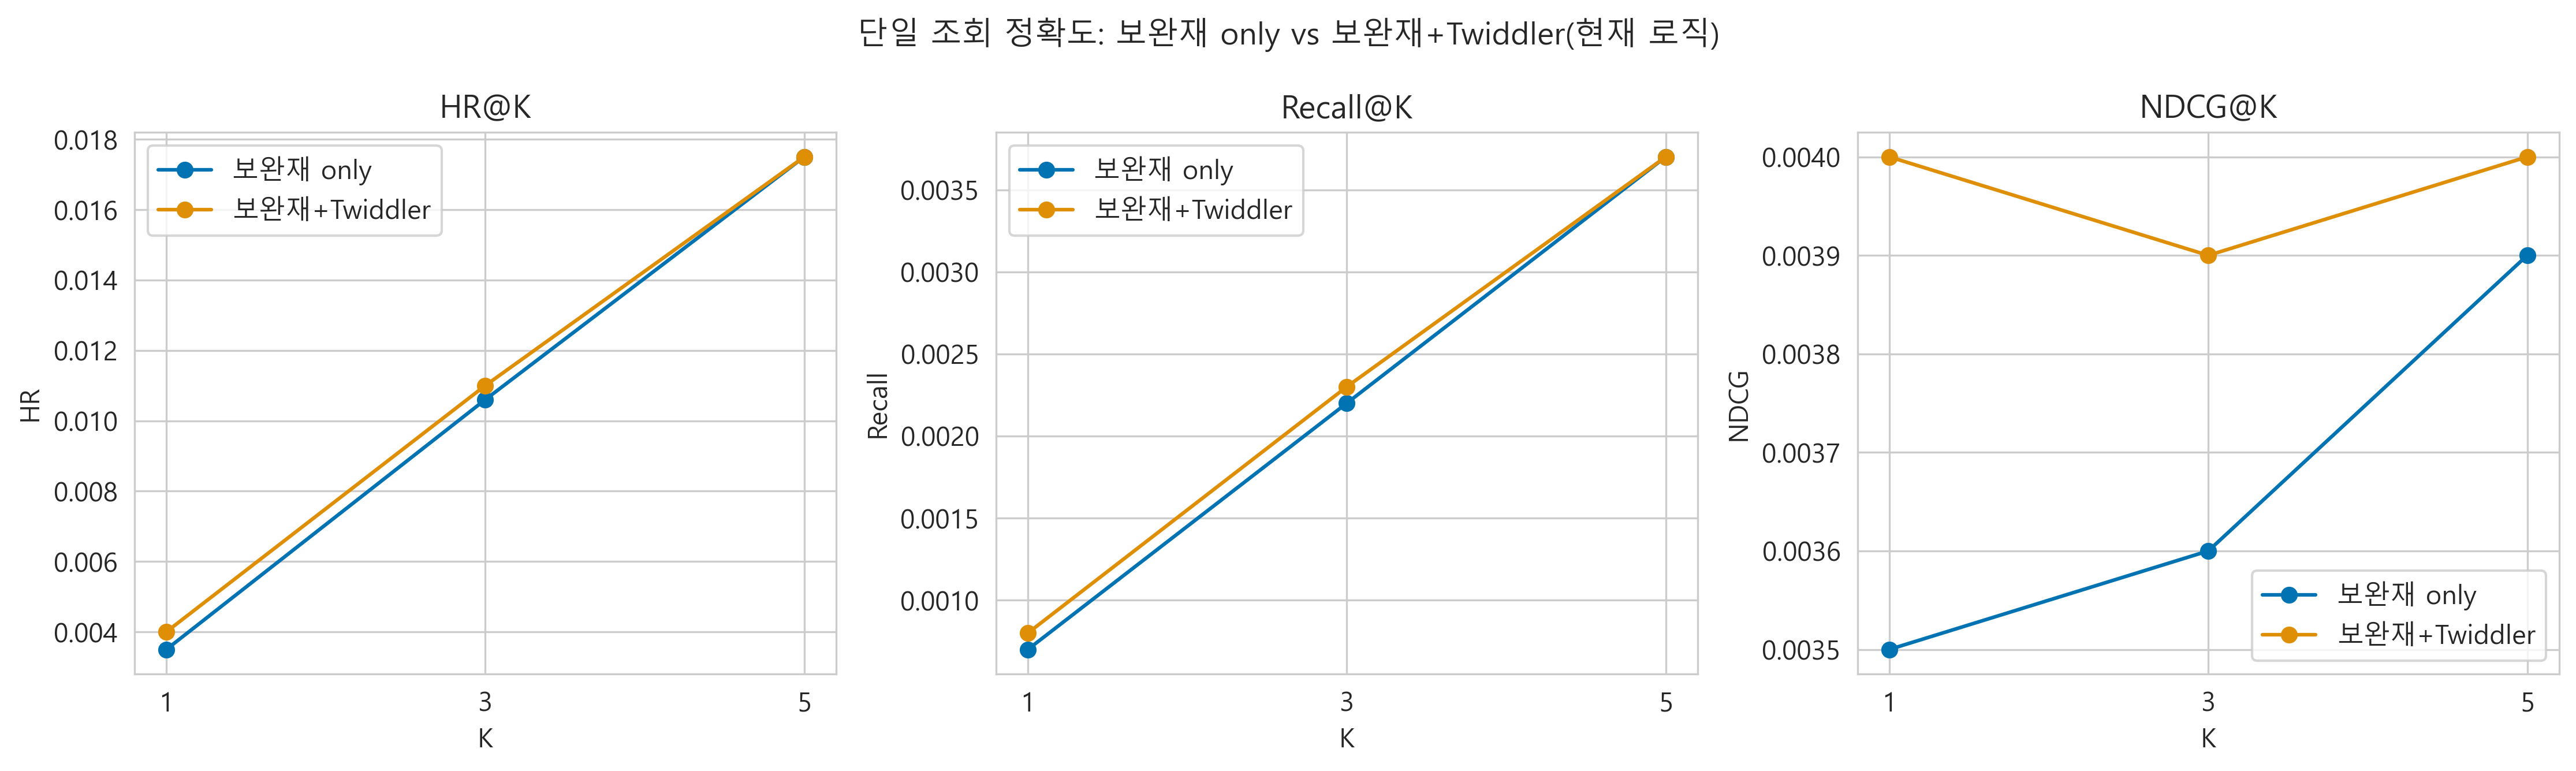

In [1]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
metrics = ["HR", "Recall", "NDCG"]
for ax, metric in zip(axes, metrics):
    for i, cond in enumerate(["comp_only", "comp_twiddler"]):
        vals = baseline_df[baseline_df["condition"] == cond].sort_values("k")[metric].values
        ax.plot(K_LIST, vals, marker="o",
                label={"comp_only": "보완재 only", "comp_twiddler": "보완재+Twiddler"}[cond],
                color=PALETTE[i])
    ax.set_xlabel("K")
    ax.set_ylabel(metric)
    ax.set_title(f"{metric}@K")
    ax.set_xticks(K_LIST)
    ax.legend()
fig.suptitle("단일 조회 정확도: 보완재 only vs 보완재+Twiddler(현재 로직)", fontsize=13)
plt.tight_layout()
plt.show()


**해석**
- K=1,3에서는 Twiddler가 HR/Recall/NDCG 모두 미세하게 개선(예: HR@1 0.0035→0.0040, HR@3 0.0106→0.0110).
  ALS 메인 추천에서 관찰된 "K=5는 개선, K=10은 하락"과 같은 뚜렷한 트레이드오프는 여기선 나타나지 않는다.
- **K=5에서는 HR/Recall이 완전히 동일**(0.0175 = 0.0175). 후보 풀 자체가 5개뿐이므로 K=5는 순서와 무관하게
  5개 전부를 보여주는 것과 같다 — Twiddler가 "무엇을 보여줄지"에는 전혀 관여하지 못하고 "어떤 순서로
  보여줄지"만 바꿀 수 있다. NDCG@5만 순서에 반응해 0.0039→0.0040으로 아주 미세하게 오른다.
- 전반적으로 절대 수치가 매우 낮다(HR 0.35%~1.75%) — 이는 Twiddler 효과라기보다 보완재 히트레이트 자체가
  낮은 합성 데이터의 특성이다(카테고리 간 조건부 확률 기반 추천이라 실제 "함께 담김" 매치가 드묾).


## 4. 반복 재방문(5회) 다양성: 보완재 only vs 보완재+Twiddler

같은 유저가 같은 상품의 상세페이지를 5회 반복 방문하는 상황을 시뮬레이션한다. `exposure_service`의
`context="detail"` 노출 이력이 `decay`(유저 개인화 감쇠율)로 매 방문마다 갱신되는 로직
(`backend/api/services/exposure_service.py::record_exposure`)을 그대로 재현했다.


In [1]:
def decay_and_record(exposure_counts, shown_ids, decay):
    for iid in list(exposure_counts.keys()):
        decayed = exposure_counts[iid] * decay
        if decayed < 0.01:
            del exposure_counts[iid]
        else:
            exposure_counts[iid] = decayed
    for iid in shown_ids:
        exposure_counts[iid] = exposure_counts.get(iid, 0.0) + 1.0


def simulate_views(candidates_base, pf, k, condition):
    if condition == "comp_only" or pf["persona"] is None:
        return [[it["rec_item_id"] for it in candidates_base[:k]] for _ in range(T_VIEWS)]
    exposure_counts = {}
    views = []
    for _ in range(T_VIEWS):
        candidates = [dict(it) for it in candidates_base]
        exposure_arg = exposure_counts if exposure_counts else None
        reranked = rerank_mod.rerank(
            candidates, id_key="rec_item_id", category_map=category_map,
            affinity=pf["affinity"], alpha=pf["alpha"],
            exposure_counts=exposure_arg, decay=pf["decay"], top_k=k,
        )
        slate = [it["rec_item_id"] for it in reranked]
        views.append(slate)
        decay_and_record(exposure_counts, slate, pf["decay"])
    return views


def diversity_metrics(views, k):
    first = set(views[0])
    overlaps = [len(first & set(v)) / k for v in views[1:]]
    all_items = [it for v in views for it in v]
    all_cats = {category_map.get(it) for it in all_items} - {None}
    first_cats = {category_map.get(it) for it in views[0]} - {None}
    return {"repetition_rate": np.mean(overlaps) if overlaps else 1.0,
            "unique_item_ratio": len(set(all_items)) / (k * len(views)),
            "categories_1view": len(first_cats), "categories_5views": len(all_cats)}


unique_item_cust = list({(t, c) for c, t, _ in cases})
print(f"다양성 시뮬레이션 대상 (item, customer) 고유 조합: {len(unique_item_cust):,}건")

diversity_rows = []
for k in K_LIST:
    for condition in ["comp_only", "comp_twiddler"]:
        acc = {"repetition_rate": [], "unique_item_ratio": [], "categories_1view": [], "categories_5views": []}
        for target_prod, cust in unique_item_cust:
            candidates_base = recs_dict[target_prod]
            pf = persona_cache[cust]
            views = simulate_views(candidates_base, pf, k, condition)
            m = diversity_metrics(views, k)
            for key in acc:
                acc[key].append(m[key])
        diversity_rows.append({
            "k": k, "condition": condition,
            "repetition_rate": round(np.mean(acc["repetition_rate"]), 4),
            "unique_item_ratio": round(np.mean(acc["unique_item_ratio"]), 4),
            "categories_1view": round(np.mean(acc["categories_1view"]), 2),
            "categories_5views": round(np.mean(acc["categories_5views"]), 2),
            "n_cases": len(acc["repetition_rate"]),
        })
diversity_df = pd.DataFrame(diversity_rows)
print("\n[표 2] 반복 재방문(5회) 다양성: 보완재 only vs 보완재+Twiddler(현재 로직)")
print(diversity_df.to_string(index=False))


다양성 시뮬레이션 대상 (item, customer) 고유 조합: 104,325건

[표 2] 반복 재방문(5회) 다양성: 보완재 only vs 보완재+Twiddler(현재 로직)
 k     condition  repetition_rate  unique_item_ratio  categories_1view  categories_5views  n_cases
 1     comp_only           1.0000             0.2000              1.00               1.00   104325
 1 comp_twiddler           0.3421             0.6599              1.00               2.42   104325
 3     comp_only           1.0000             0.2000              2.40               2.40   104325
 3 comp_twiddler           0.6342             0.3316              2.33               3.26   104325
 5     comp_only           1.0000             0.2000              3.28               3.28   104325
 5 comp_twiddler           1.0000             0.2000              3.28               3.28   104325


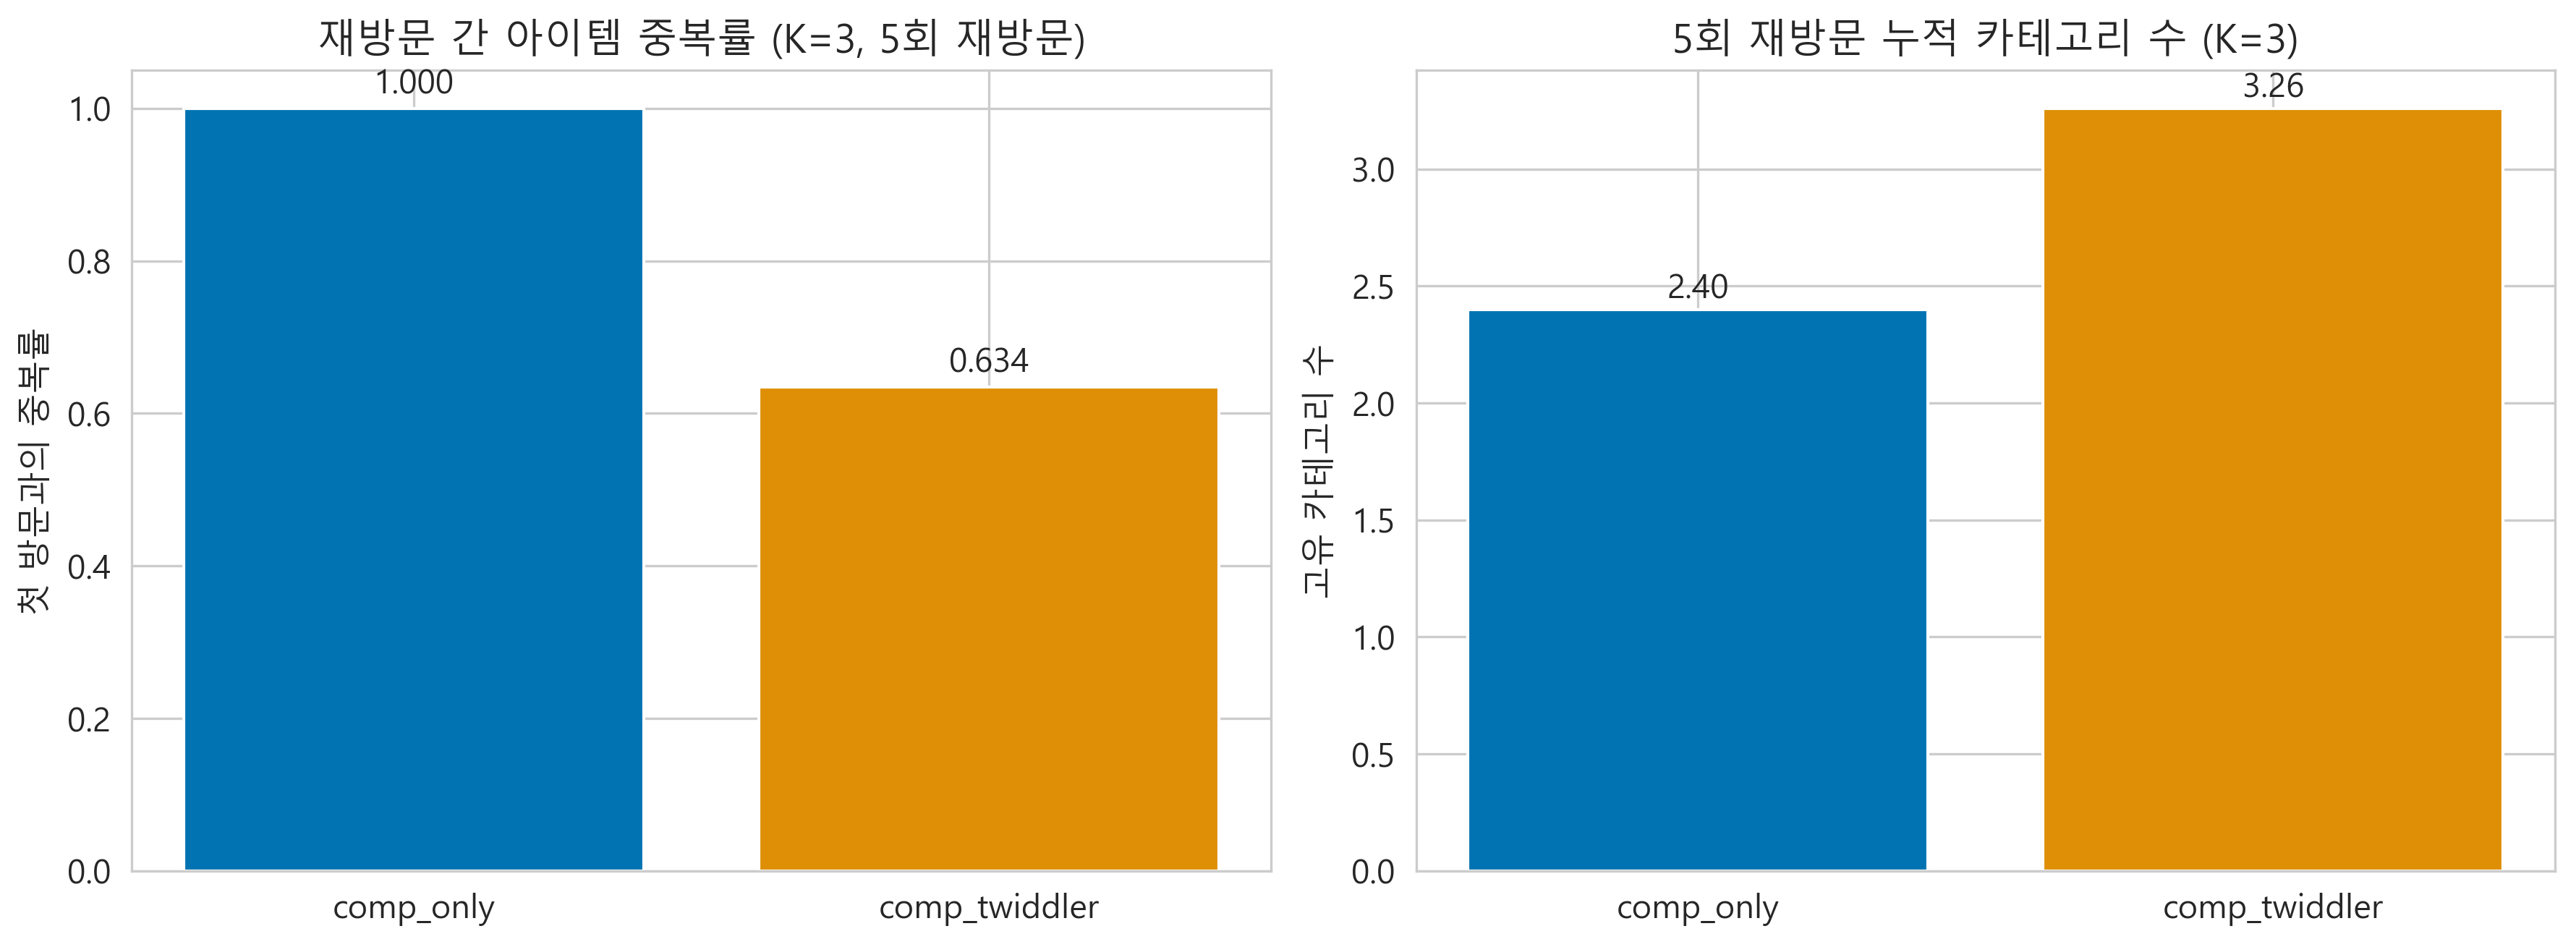

In [1]:
fig2, axes2 = plt.subplots(1, 2, figsize=(12, 4.5))
sub = diversity_df[diversity_df["k"] == 3]
axes2[0].bar(sub["condition"], sub["repetition_rate"], color=PALETTE[:2])
axes2[0].set_title("재방문 간 아이템 중복률 (K=3, 5회 재방문)")
axes2[0].set_ylabel("첫 방문과의 중복률")
axes2[0].set_ylim(0, 1.05)
for i, v in enumerate(sub["repetition_rate"]):
    axes2[0].text(i, v + 0.02, f"{v:.3f}", ha="center")

axes2[1].bar(sub["condition"], sub["categories_5views"], color=PALETTE[:2])
axes2[1].set_title("5회 재방문 누적 카테고리 수 (K=3)")
axes2[1].set_ylabel("고유 카테고리 수")
for i, v in enumerate(sub["categories_5views"]):
    axes2[1].text(i, v + 0.05, f"{v:.2f}", ha="center")

plt.tight_layout()
plt.show()


**해석**
- K=1: 중복률 100%→34.2%, 5회 누적 카테고리 1.00→2.42개. K=3: 100%→63.4%, 2.40→3.26개 — Rule 2가 재방문마다
  후보 5개 내에서 노출된 아이템의 점수를 깎아 순서를 바꾸는 만큼, 좁은 K에서는 뚜렷한 다양성 개선이 있다.
- **K=5에서는 두 조건이 완전히 동일하다(중복률 100%, 카테고리 3.28개로 동일)** — 위에서 확인했듯 후보가
  정확히 5개뿐이므로 K=5는 항상 "그 5개 전부"를 보여준다. 재방문마다 순서만 바뀔 뿐 노출되는 아이템 집합
  자체는 절대 바뀌지 않는다. 즉 **Rule 2의 다양성 효과는 "표시 개수(K) < 후보 풀 크기"일 때만 발생**한다.
- 이는 ALS 메인 추천(후보 풀이 `k×pool_multiplier`로 항상 K보다 커서 K=20에서도 다양성 효과가 유지됨,
  categories_5sessions 4.28→4.93)과 대비된다. 보완재는 후보 풀 자체가 파이프라인 단계에서 5개로 고정돼
  있어, 실제 서비스에서 상세페이지에 5개 미만(예: 3개)을 노출할 때만 Rule 2가 의미를 갖는다.


## 5. 가중치 의미 예시 — 상품 1개 × 유저 3명

같은 상품(`item_id=1`, Electronics)의 상세페이지를 보고 있는 서로 다른 유저 3명이 동일한 5개 후보를
얼마나 다르게 재정렬해서 보게 되는지 비교한다(모두 K=5, 노출 이력 없는 첫 방문 기준).


In [1]:
example_item = 1
print(f"[예시 상품] item_id={example_item}, 카테고리={category_map.get(example_item)}")
print("후보(원본 순서):")
for it in recs_dict[example_item]:
    print(f"  rec_item_id={it['rec_item_id']:>5}  score={it['score']:.4f}  category={category_map.get(it['rec_item_id'])}")

sample_uids = [222, 4167, 31]  # ALS 노트북 케이스 스터디와 동일 유저 재사용
example_rows = []
for uid in sample_uids:
    pf_label = persona_service.get_persona(uid)
    affinity = persona_service.get_user_affinity(uid)
    alpha = persona_service.get_user_alpha(uid)
    decay = persona_service.get_user_decay(uid)
    candidates = [dict(it) for it in recs_dict[example_item]]
    reranked = rerank_mod.rerank(
        candidates, id_key="rec_item_id", category_map=category_map,
        affinity=affinity, alpha=alpha, exposure_counts=None, top_k=5,
    )
    order = [it["rec_item_id"] for it in reranked]
    top_category = max(affinity, key=affinity.get) if affinity else None
    example_rows.append({
        "user_id": uid, "persona(segment_name)": pf_label,
        "alpha(Rule1 강도)": round(alpha, 3), "decay(Rule2 감쇠율)": round(decay, 3),
        "선호 카테고리": top_category,
        "선호 카테고리 편차": round(affinity.get(top_category, 0), 3) if top_category else None,
        "재랭킹 후 순서": order,
    })
example_df = pd.DataFrame(example_rows)
print("\n[표 3] 상품 하나에 대한 유저별 재랭킹 결과 비교")
print(example_df.to_string(index=False))


[예시 상품] item_id=1, 카테고리=Electronics
후보(원본 순서):
  rec_item_id= 1105  score=0.0659  category=Toys
  rec_item_id=  256  score=0.0299  category=Home & Kitchen
  rec_item_id=  831  score=0.0240  category=Fashion
  rec_item_id=  389  score=0.0240  category=Beauty
  rec_item_id=  890  score=0.0240  category=Books

[표 3] 상품 하나에 대한 유저별 재랭킹 결과 비교
 user_id                       persona(segment_name)  alpha(Rule1 강도)  decay(Rule2 감쇠율) 선호 카테고리  선호 카테고리 편차                   재랭킹 후 순서
     222  Frequent Viewers with Consistent Purchases            1.500             0.832   Books       0.857  [1105, 890, 256, 831, 389]
    4167           High-Engagement Repeat Purchasers            0.039             0.501  Beauty       0.357  [1105, 256, 389, 831, 890]
      31 Frequent Browsers with Occasional Purchases            0.750             0.705   Books       0.357  [1105, 890, 256, 831, 389]


**해석**
- 원본 순서는 `[1105(Toys), 256(Home&Kitchen), 831(Fashion), 389(Beauty), 890(Books)]`.
- 유저 222(Books 선호, 편차 0.857, alpha=1.5 — 최댓값)는 4위였던 890(Books)을 2위로 크게 끌어올린다
  (`[1105, 890, 256, 831, 389]`). alpha가 크고 편차가 클수록 재정렬 폭이 크다.
- 유저 31도 같은 Books 선호지만 편차가 0.357로 더 작고 alpha=0.75(222의 절반)라 890이 2위까지만 오르는
  건 같지만 밀어올리는 힘 자체는 222보다 약하다 — 같은 세그먼트 서사(`Frequent Browsers...`)를 공유하지
  않는 유저라도 alpha/편차 조합이 다르면 결과가 달라짐을 보여준다.
- 유저 4167은 alpha=0.039로 거의 0에 가깝다(충성도가 낮고 탐색 성향이 매우 높은 유저 — `alpha = base_alpha
  × category_loyalty × (1-exploration_tendency)`에서 두 항 모두 작음). 결과적으로 원본 순서와 거의 같고
  256과 389의 순서만 미세하게 바뀐다 — "탐색형 유저는 카테고리 편향을 거의 주지 않는다"는 설계 의도가
  그대로 관찰된다.


## 결과 요약

**핵심 발견**
- 정확도: K=1,3에서 Twiddler가 HR/Recall/NDCG를 소폭 개선(예: HR@1 +14%, HR@3 +4%). **K=5에서는 HR/Recall이
  후보 풀 크기(5)와 K가 같아져 두 조건이 완전히 동일** — Twiddler는 이 도메인에서 "무엇을 보여줄지"가 아니라
  "어떤 순서로 보여줄지"만 바꾼다.
- 다양성: K<5(=후보 풀 크기)일 때만 Rule 2의 재방문 다양성 효과가 나타난다(K=1 중복률 100%→34.2%, K=3
  100%→63.4%). K=5에서는 효과가 완전히 사라진다(양쪽 다 100%, 카테고리 3.28개로 동일).
- 개인화 강도(alpha)는 유저별로 0.039~1.5까지 넓게 분포하며, 선호 카테고리 편차와 함께 재정렬 폭을 결정한다
  — 세그먼트 평균이 아니라 유저 단위 값을 쓰는 설계 의도가 예시에서 직접 확인된다.

**수치 요약**

| 조건 | HR@3 | HR@5 | 재방문 중복률(K=3) | 5회 누적 카테고리(K=3) |
|---|---|---|---|---|
| 보완재 only | 0.0106 | 0.0175 | 1.0000 | 2.40 |
| 보완재+Twiddler | 0.0110 | 0.0175 | 0.6342 | 3.26 |

**해석**: 보완재 추천에서 Twiddler의 가치는 ALS 메인 추천과 마찬가지로 정확도가 아니라 반복 방문 시 다양성
확보에 있다. 다만 이 도메인은 후보 풀이 파이프라인 단계에서 이미 5개로 절단되어 있어, 실제 서비스에서
상세페이지에 5개 미만을 노출할 때만 다양성 효과가 발생한다는 **도메인 고유의 제약**이 ALS 노트북과 다른
지점이다.

**한계**
- 합성(Faker 생성) 데이터 기반으로, 절대 HR 값 자체는 매우 낮아(0.35~1.75%) 실제 서비스 성능을 대표하지
  않는다. 조건 간 상대적 방향성 위주로 해석해야 한다.
- 후보 풀이 5개로 고정된 것은 `run_bowanjae_pipeline.py`의 `groupby('prod_A').head(5)` 설계 때문이며,
  파이프라인에서 상품당 저장 개수를 늘리면(예: top-10) Rule 2의 다양성 효과가 K=5 이상에서도 나타날 수
  있다 — 이번 노트북은 현재 저장된 값 기준으로만 평가했다.
- 페르소나 특징 테이블(`customer_segments_labeled_train_only.csv`)이 20,000명 전체를 커버해 이 평가에서는
  페르소나 미존재로 인한 폴백 케이스가 없었다(ALS 노트북의 cold-start 유저와 다른 지점).

**권장 다음 단계**
- 상품당 저장 후보 개수를 5개보다 늘려(`run_bowanjae_pipeline.py` top_n 조정) K=5~8 구간에서도 다양성
  효과가 발생하는지 재확인.
- 인터프리터빌리티(XAI) 설명 레이어를 이 상세페이지 재랭킹 결과에도 붙여, "왜 이 순서로 보여줬는지"를
  유저에게 설명 가능하게 하는 방안(현재 별도 이슈로 제안됨).
